In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import random

from xps_datagen.NNDataBuilderPeter import *
from xps_datagen.DatasetObjects import SpectrumDataset
from xsw_profile.predict_modulation import predict_modulation
from xps_extension import *
from networks.NNModels import build_cnn

In [6]:
NUM_PEAKS = 3

In [49]:
random.seed = 37
num_spectra = 1
xsw_dataset = {
    'xsw_curve': [],
    #'e_range': [],
    'cs': [],
    'cs_norm': [],
    #'modulation': [],
    'coh_params': [],
    'mod_width': [],
}
#for i in range(num_spectra):
    print(i)
    coh_params = []
    modulations = []
    mod_width = random.gauss(0.3, 0.066)
    while mod_width <= 0:
        mod_width = random.gauss(0.3, 0.066)
    for i in range(NUM_PEAKS):
        c_frac, c_pos = random.uniform(0,1), random.uniform(0,1)

        modulation_i = predict_modulation(
            data_dir=Path("fpfpp/"),
            coherent_fraction=c_frac,
            coherent_position=c_pos,
            theta=18,
            plotter=1,
            atom_type=5,
            principal_qn=1,
            azimuthal_qn=0,
            spin_qn=0.5,
            alphaB=0,
            hkl_index=(1, 1, 1),
            lps0=np.array([3.6149, 3.6149, 3.6149, 90, 90, 90]),
            width = mod_width,
            xyzs=np.array(
                [
                    [29, 0.0, 0.0, 0.0, 1],
                    [29, 0.5, 0.5, 0.0, 1],
                    [29, 0.5, 0.0, 0.5, 1],
                    [29, 0.0, 0.5, 0.5, 1],
                ]
            )
        )
        coh_params.append(c_frac)
        coh_params.append(c_pos)
        modulations.append(modulation_i)
  
    #print(mod_width, coh_params)

    cs_norm = gen_cs(num_spectra = 1, 
                       num_peaks = NUM_PEAKS, 
                       edge_marg = 0.1,
                       cutoff_higher=1)
    cs = rescale_cs(cs_norm)
    build_spectra(cs, plot=True)

    xsw = (extend_cs( #un-numpy arrayed
    cs = cs, 
    num_peaks = NUM_PEAKS,
    modulations = modulations, 
    lower_bound = -5, 
    upper_bound = 5, 
    num_plots_x = 4, 
    num_plots_y = 4, 
    plot = 1
    )
    )

    #print(max(modulations[0, :]))

    #print(np.array(xsw).shape, cs[0])
    #get_xsw_profile(xsw, cs, True)

    resized_spectra, e_range = resize_spectra(xsw)
    
    #print(resized_spectra.shape)

    #e_scale = np.linspace(e_range[0][0], e_range[0][1], resized_spectra.shape[1])
    #sum_spectra = [0] * resized_spectra.shape[1]
    #min_val, max_val = 0, 0
    #for i in range(resized_spectra.shape[0]):
    #    sum_spectra = sum_spectra + resized_spectra[i][:]

    
    normalised_spectra = minmax_scale(resized_spectra, True)
    #print(normalised_spectra)
    flattened_spectra = normalised_spectra.flatten()


    xsw_dataset['xsw_curve'].append(flattened_spectra)
    xsw_dataset['cs_norm'].append(cs_norm)
    xsw_dataset['cs'].append(cs)
    #xsw_dataset['modulation'].append(modulations)
    xsw_dataset['mod_width'].append([mod_width])
    xsw_dataset['coh_params'].append(coh_params)

IndentationError: unexpected indent (1022376113.py, line 13)

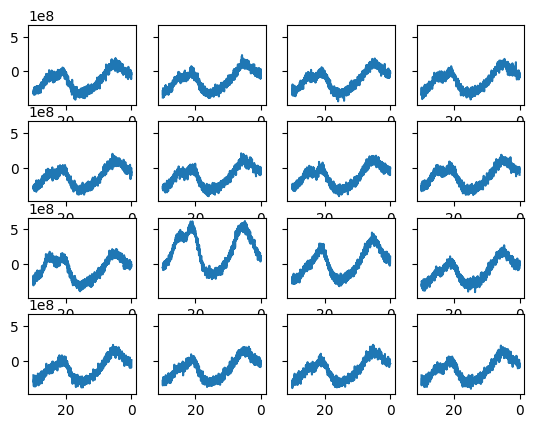

135
2171 16
1
2
3
4


IndexError: index 540 is out of bounds for axis 0 with size 504

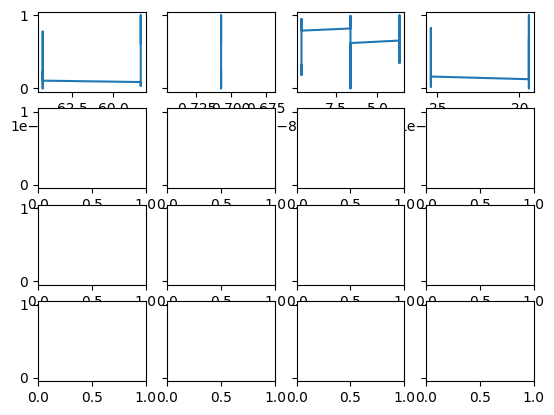

In [ ]:
xsw = (extend_cs( #un-numpy arrayed
    cs = cs, 
    num_peaks = NUM_PEAKS,
    modulations = modulations, 
    lower_bound = -5, 
    upper_bound = 5, 
    num_plots_x = 4, 
    num_plots_y = 4, 
    plot = 1
    )
    )
#plt.plot(xsw[0:100])
#print(xsw[0][31], xsw[0][31])

normalised_spectra_2 = minmax_scale(xsw, True)

num_plots_x = 4
num_plots_y = 4

lower_bound = -5
upper_bound = 5

current_sample = []
current_curve = modulations[i][0] #result of predict modulation: two arrays, absorption curve, and reflectivity curve.
for tuple in current_curve:
    if tuple[0] >= lower_bound and tuple[0] <= upper_bound:
        current_sample.append(tuple)
    #curve_samples.append(current_sample)

num_plots = num_plots_x * num_plots_y
fig, ax = plt.subplots(num_plots_y, num_plots_x, sharey = True)
count = 0
interval = len(current_sample)//num_plots
for ax in fig.get_axes():
    ax.plot(normalised_spectra_2[interval*count][0], normalised_spectra_2[interval*count][1])
    ax.xaxis.set_inverted(True)
    count += 1
    print(count)

In [37]:
def _bytes_feature(value):
  """Returns a bytes_list from a string / byte."""
  if isinstance(value, type(tf.constant(0))):
    value = value.numpy() # BytesList won't unpack a string from an EagerTensor.
  return tf.train.Feature(bytes_list=tf.train.BytesList(value=value))

def _float_feature(value):
  """Returns a float_list from a float / double."""
  return tf.train.Feature(float_list=tf.train.FloatList(value=value))

def _int64_feature(value):
  """Returns an int64_list from a bool / enum / int / uint."""
  return tf.train.Feature(int64_list=tf.train.Int64List(value=value))

In [38]:
with tf.io.TFRecordWriter(path = 'testrecords.tfrecords') as writer:
    for i in range(num_spectra):
        #print(i)
        features = {
            'xsw_curve': _float_feature(xsw_dataset['xsw_curve'][i]),
            'cs': _float_feature(xsw_dataset['cs'][i][:, 0]),
            'cs_norm': _float_feature(xsw_dataset['cs_norm'][i][:, 0]),
            #'modulations': _float_feature(xsw_dataset['modulation'][0]),
            'mod_width': _float_feature(xsw_dataset['mod_width'][i]),
            'coh_params': _float_feature(xsw_dataset['coh_params'][i])
        }
        example = tf.train.Example(features = tf.train.Features(feature = features))
        serialized_example = example.SerializeToString()
        writer.write(serialized_example)
        

KeyboardInterrupt: 

In [ ]:
raw_dataset = tf.data.TFRecordDataset('Z:/datagen/1PeakC1sData/50000records1of10.tfrecords') #all tf.train.Example messages
raw_example = next(iter(raw_dataset))
parsed = tf.train.Example.FromString(raw_example.numpy())
#print(parsed)
features_dict = {
    'xsw_curve': tf.io.FixedLenFeature(shape = (504, 200 ,1), dtype = tf.float32),
    'cs_norm': tf.io.FixedLenFeature(shape = (46,1), dtype = tf.float32),
    'mod_params': tf.io.FixedLenFeature(shape = (3,1), dtype = tf.float32)
}

dataset = raw_dataset.map(map_func = lambda serialized: tf.io.parse_single_example(serialized=serialized, features = features_dict))
dataset = dataset.map(map_func = lambda features:
                      (#features['xsw_curve'],
                       tf.gather(features['cs_norm'], 10)
                      )
                   )

#dataset = dataset.shuffle(buffer_size=dataset.cardinality())
#dataset = dataset.repeat()
#dataset = dataset.batch(3200, drop_remainder = True)
next(dataset.as_numpy_iterator()).shape

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_1_device_/job:localhost/replica:0/task:0/device:CPU:0}} Error in user-defined function passed to MapDataset:69 transformation with iterator: Iterator::Root::ParallelMapV2::ParallelMapV2: Key: xsw_curve.  Can't parse serialized Example.
	 [[{{node ParseSingleExample/ParseExample/ParseExampleV2}}]] [Op:IteratorGetNext] name: 

In [ ]:
#model, hyper_param = build_cnn(
#    input_size=200,
#    num_kernels=(16, 16, 16),  # 3 convolutionals for position finding.
#    kernel_size=(16, 32, 48),
#    conv_drop=(0, 0, 0),  # No dropout on convolutionals
#    dense_units=(500, 300, NUM_PEAKS),
#    dense_drop=(0.2, 0.2),  # Lighter dropout for position finding.
#    loss="mae",  # Regression tasks should use mean absolute or quadratic loss.
#    metrics="mse",  # Another regression metric to keep track of.
#    activations=(
#        "relu",
#        "sigmoid",
#    ),  # Sigmoid rescales outputs to (0,1), but doesn't enforce summation to unity.
#    learning_rate=0.001,
#    name=None,
#)

#model = tf.keras.Sequential()
#model.add(tf.keras.layers.Conv1D(
#                filters=16,
#                kernel_size=(16,),
#                padding="same",
#                activation='relu',
#                input_shape=(200,1),
#                name="Conv1",
#            ))
#model.add(tf.keras.layers.Dropout(rate=0, name="Conv1_Drop"))
#model.add(tf.keras.layers.Conv1D(
#                filters=16,
#                kernel_size=(32,),
#                padding="same",
#                activation='relu',
#                name="Conv2",
#            ))
#model.add(tf.keras.layers.Dropout(rate=0, name="Conv2_Drop"))
#model.add(tf.keras.layers.Conv1D(
#                filters=16,
#                kernel_size=(48,),
#                padding="same",
#                activation='relu',
#                name="Conv3",
#            ))
#model.add(tf.keras.layers.Dropout(rate=0, name="Conv3_Drop"))
#model.add(tf.keras.layers.Flatten(name="Flatten"))

#model.add(
#            tf.keras.layers.Dense(
#                500, activation='relu', name="Dense1"
#            )
#        )
#model.add(tf.keras.layers.Dropout(0.2, name="Dense1_Drop"))

#model.add(
#            tf.keras.layers.Dense(
#                300, activation='relu', name="Dense2"
#            )
#        )       
#model.add(tf.keras.layers.Dropout(0.2, name="Dense2_Drop"))

#model.add(
#        tf.keras.layers.Dense(200, activation='sigmoid', name="DenseOut")
#)

#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001,),
#              loss = 'mae',
#              metrics = ['accuracy'])

#model.fit(dataset, epochs = 10)